# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [23]:
import sys
import os

# Ajoute le dossier parent de `experiments` au path
sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from modules.kgd_functions import F_P, GradientKernel,KernelGradientDiscrepancy, k_imq
from modules.kgd_descent import KGD_Descent


import jax
from jax import random

In [24]:
device_name = "cpu"

In [25]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

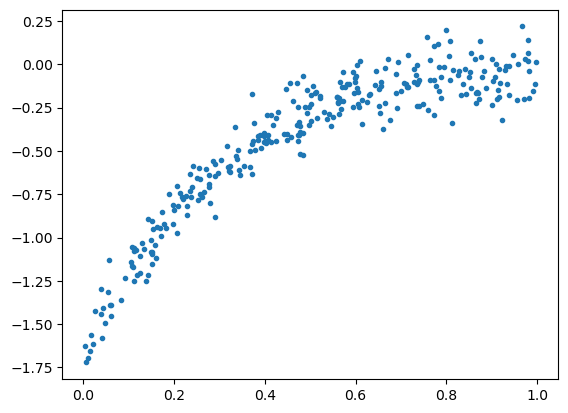

In [26]:
def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [0,1]

    def target_function(z):
        params = jnp.array([2, 0.5, 3, -3])
        return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]

    Y_clean = target_function(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z_train, Y_train = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
key, subkey = random.split(key)
Z_test, Y_test = generate_data(subkey, s, N=N, noise_std=0.1)

device = jax.devices()[0]
Z_train, Y_train = jax.device_put((Z_train, Y_train), device)
plt.plot(Z_train, Y_train, ".")

In [27]:
def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*0.5))

def grad_log_q0(X):
    return -X/0.5


def L(X, unravel_fn, gamma=100):
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z_train)
    return gamma * jnp.mean((Esp_forward - Y_train) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)

gamma = 300
L_ = jit(lambda X: L(X, unravel_fn, gamma))

scale = 1e-0
k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))

KGD_D = KGD_Descent(grad_log_q0, L_, k)

In [28]:
T = 20000
n = 100
learning_rate = 1e-2

key = random.PRNGKey(1)
init_std = 3
X0 = init_std*random.normal(subkey, shape=(n, d))

all_particles = KGD_D.run_particles(X0,T,learning_rate = learning_rate)
X_fin = all_particles[-1]

Step 0, loss = 80.1474380493164, mse = 0.31291669607162476
Step 10, loss = 21.90504264831543, mse = 0.2550853192806244
Step 20, loss = 25.37698745727539, mse = 0.25129881501197815
Step 30, loss = 20.204832077026367, mse = 0.23685401678085327
Step 40, loss = 17.802135467529297, mse = 0.2273697704076767
Step 50, loss = 16.759944915771484, mse = 0.21664799749851227
Step 60, loss = 15.782624244689941, mse = 0.20659011602401733
Step 70, loss = 14.83055591583252, mse = 0.19703644514083862
Step 80, loss = 13.937461853027344, mse = 0.1879776269197464
Step 90, loss = 13.111207962036133, mse = 0.17952531576156616
Step 100, loss = 12.347832679748535, mse = 0.17175112664699554
Step 110, loss = 11.643275260925293, mse = 0.16451199352741241
Step 120, loss = 10.994717597961426, mse = 0.15786494314670563
Step 130, loss = 10.398360252380371, mse = 0.1517036408185959
Step 140, loss = 9.848621368408203, mse = 0.14596907794475555
Step 150, loss = 9.341270446777344, mse = 0.1406169831752777
Step 160, loss 

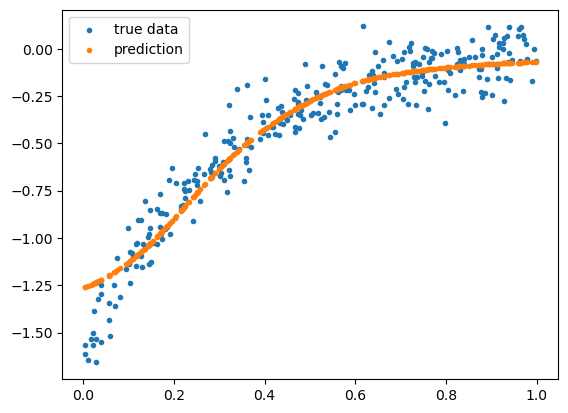

In [29]:
#Prediction function 
plt.scatter(Z_test,Y_test,label = "true data",marker = ".")
Y_hat = vmap(lambda z: forward_(X_fin, z, unravel_fn))(Z_test)
plt.scatter(Z_test,Y_hat,label = "prediction",marker = ".")
plt.legend()

Text(0, 0.5, 'dim4')

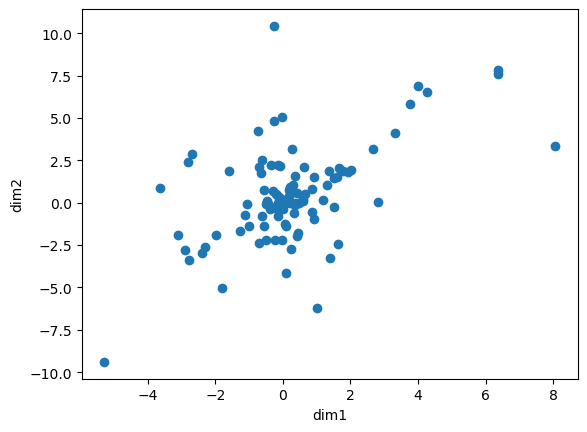

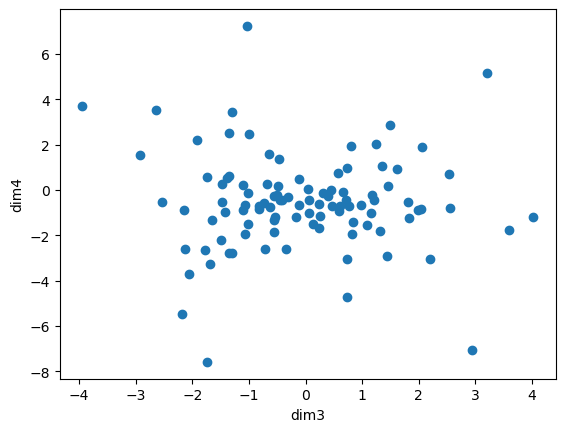

In [32]:
#Final particles positions
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.xlabel("dim1")
plt.ylabel("dim2")
plt.figure()
plt.scatter(X_fin[:,2], X_fin[:,3])
plt.xlabel("dim3")
plt.ylabel("dim4")

Text(0.5, 1.0, 'KGD values over iterations')

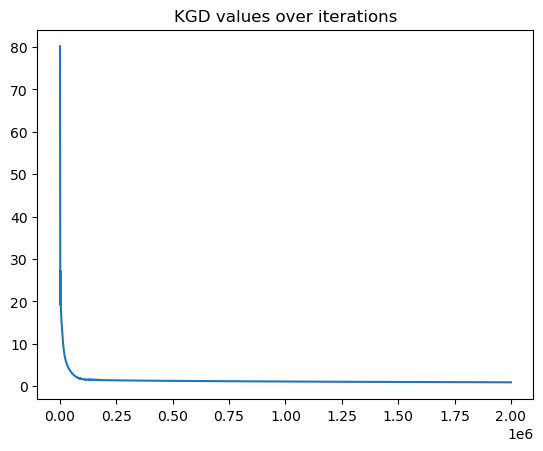

In [31]:
k_pq = GradientKernel(KGD_D.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

KGD_values = []
eval_gradL = jnp.arange(0,T)*n
for it in range(T):
    KGD_values.append(KGD.evaluate(all_particles[it]))


plt.plot(eval_gradL,KGD_values)
plt.title("KGD values over iterations")

# Save data

In [33]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open("saved_data/expe2_results.pkl", "rb") as g:
    expe2_results = pickle.load(g)

In [34]:
expe2_results["KGD Descent"]["X_fin"] = X_fin
expe2_results["KGD Descent"]["KGD_values"] = KGD_values
expe2_results["KGD Descent"]["gradL_eval"] = eval_gradL

In [35]:
import pickle

# Sauvegarde dans un fichier binaire
with open("saved_data/expe2_results.pkl", "wb") as gg:
    pickle.dump(expe2_results, gg)